PROJECT 1: Breast Cancer classification(binary)
Goal: Predict if a tumor is malignant or benign using built-in dataset
Dataset: load_Breast-Cancer() from sklearn

In [ ]:
# step one: import libraries
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt



In [19]:
import sys
print(sys.executable)

/home/ghazale/miniconda3/envs/new-env/bin/python


In [20]:
import pandas as pd
print(pd.__version__)

3.0.3


In [ ]:
# step2: load the built-in breast cancer dataset from sklearn
# X hoodes 30 numeric features (like radius, texture) for 569 patients
# y holds labales: 0 =malignant(cancerous) , 1 = benign (non-cancerous)
# I printed the class distribution to check for imbalance before modeling
X = data.data            
y = data.target          
feature_names = data.feature_names
target_names = data.target_names

print(f"dataset shape: {X.shape}")
print(f"Classes: {target_names}")
print(f"Class distribution:\n{pd.Series(y).value_counts()}")


dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Class distribution:
1    357
0    212
Name: count, dtype: int64


In [ ]:
# step3: split into train (80%) and test (20%)
# random_state=42 makes the split repoducible (same split every run)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (455, 30)
X_test shape (114, 30)
y_train shape: (455,)
y_test shape: (114,)


In [24]:
print(f"Original dataset: {X.shape[0]} patients")
print(f"Training set: {X_train.shape[0]} patients")
print(f"Testing set: {X_test.shape[0]} patients")
print(f"Training labels distribution:\n{pd.Series(y_train).value_counts()}")
print(f"Testing labels distribution:\n{pd.Series(y_test).value_counts()}")

Original dataset: 569 patients
Training set: 455 patients
Testing set: 114 patients
Training labels distribution:
1    286
0    169
Name: count, dtype: int64
Testing labels distribution:
1    71
0    43
Name: count, dtype: int64


In [ ]:
# step4: train a random forest with 100 decision trees
# random forest works by combinig many trees and taking a majority vote
# i chose this over a single decision tre because it's more stable and less prone to overfitting
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
#step5: predict and evaluate
y_pred = model.predict(X_test)
acuracy = accuracy_score(y_test, y_pred)
print(f"\nacuracy: {accuracy:.3f}")


acuracy: 0.965


In [27]:
# Find which patients were misclassified
errors = (y_test != y_pred)
print(f"Number of errors: {errors.sum()} out of {len(y_test)}")
print(f"Accuracy: {(len(y_test) - errors.sum()) / len(y_test):.3f}")

Number of errors: 4 out of 114
Accuracy: 0.965


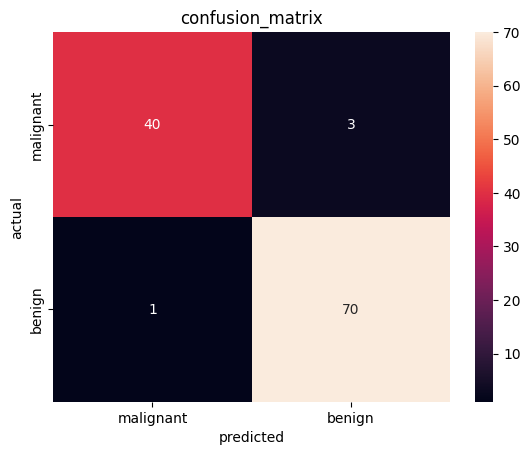

In [28]:
#step6: confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt= 'd', xticklabels=target_names, yticklabels=target_names)
plt.title('confusion_matrix')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

In [ ]:
# manually Calculating key medical metrics from the confusion matrix
#sensitivity = how well the model catches actual cancer cases
# specificity = how well it identifies healthy patients
# I calculate these manually instead of just using classification_report to understand what they meann 
tn, fp, fn, tp = cm.ravel()  # tn=70, fp=1, fn=3, tp=40

sensitivity = tp / (tp + fn)  # True positive rate (detects cancer)
specificity = tn / (tn + fp)  # True negative rate (identifies healthy)
precision = tp / (tp + fp)    # When predicts cancer, how often correct?

print(f"Sensitivity (Recall): {sensitivity:.3f}")  # 40/43 = 0.930
print(f"Specificity: {specificity:.3f}")           # 70/71 = 0.986
print(f"Precision: {precision:.3f}")               # 40/41 = 0.976

Sensitivity (Recall): 0.986
Specificity: 0.930
Precision: 0.959


In [32]:
# Step 7: Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))




Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
# Step 8: which feature does the model rely on most?
# this helps interperter the model not just "it works" but "wht it works"
# higher importance = that measurment was more useful for the decision
importances = model.feature_importances_
top_indices = np.argsort(importances)[-5:]
print("\nTop 5 most important features:")
for i in top_indices:
    print(f"  {feature_names[i]}: {importances[i]:.3f}")



Top 5 most important features:
  mean concavity: 0.068
  worst radius: 0.078
  mean concave points: 0.106
  worst concave points: 0.145
  worst area: 0.154


"The top features wew mostly related to cell size and shape measurments, which makes biological sense, since cancerous cells tend to be irregular and larger than normal cells"

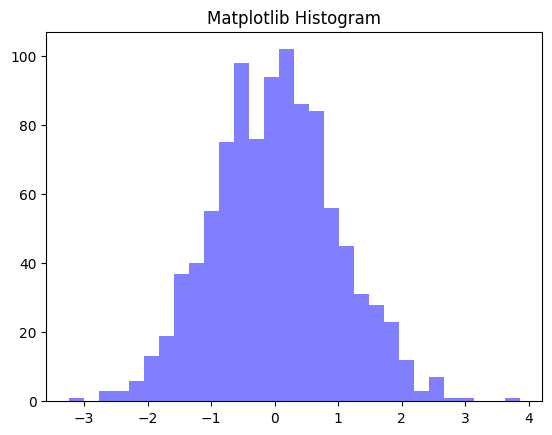

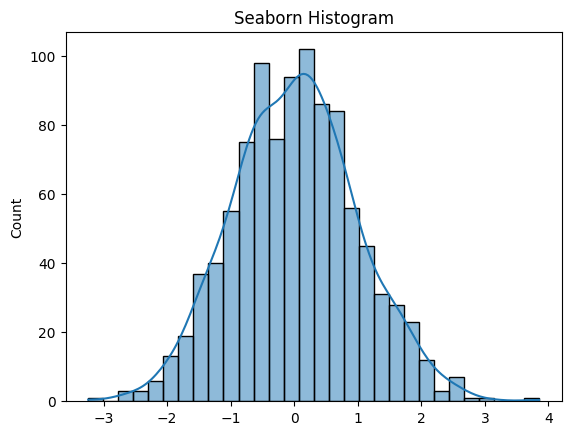

In [17]:
# Create some fake data
import numpy as np
np.random.seed(42)
data = np.random.randn(1000)

# Matplotlib version
plt.hist(data, bins=30, color='blue', alpha=0.5)
plt.title('Matplotlib Histogram')
plt.show()

# Seaborn version (prettier)
sns.histplot(data, bins=30, kde=True)  # kde adds smooth curve
plt.title('Seaborn Histogram')
plt.show()